In [1]:
# MARKDOWN CELL
# ## Phase 2 — Bottleneck & Corridor Audit
#
# Phase 1 built the graph. Phase 2 interrogates it.
#
# We run a structured audit across three levels:
# 1. **Hub level**      — which hubs are structural bottlenecks
# 2. **Corridor level** — which routes are chronically delayed
# 3. **Network level**  — patterns by state, time, route type

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os
import warnings
 
warnings.filterwarnings("ignore")
 
# Consistent plot style across all charts
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120
 
print("Imports ready")

Imports ready


In [3]:
OUT_DIR = "../data/processed"
VIZ_DIR = "../outputs/phase2_visuals"
os.makedirs(VIZ_DIR, exist_ok=True)
 
# Load everything Phase 1 saved
G                   = nx.read_graphml(f"{OUT_DIR}/delivery_network.graphml")
node_metrics        = pd.read_csv(f"{OUT_DIR}/node_metrics.csv")
corridor_aggregates = pd.read_csv(f"{OUT_DIR}/corridor_aggregates.csv")
corridor_stratified = pd.read_csv(f"{OUT_DIR}/corridor_stratified.csv")
train_df            = pd.read_csv(f"{OUT_DIR}/train_clean.csv",
                                  parse_dates=["od_start_time", "trip_creation_time"])
 
print("Loaded successfully")
print(f"  Graph               : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"  node_metrics        : {node_metrics.shape}")
print(f"  corridor_aggregates : {corridor_aggregates.shape}")
print(f"  corridor_stratified : {corridor_stratified.shape}")
print(f"  train_df            : {train_df.shape}")

Loaded successfully
  Graph               : 1657 nodes, 2783 edges
  node_metrics        : (1657, 18)
  corridor_aggregates : (2783, 12)
  corridor_stratified : (4565, 13)
  train_df            : (103049, 27)


In [4]:
# Part 1 — Hub Level Audit
#
# For each hub we look at:
# - **Bottleneck score** — our composite ranking from Phase 1
# - **Betweenness centrality** — structural importance in the network
# - **SLA breach rate** — % of outgoing trips that are late
# - **Out-degree** — how many corridors this hub feeds into

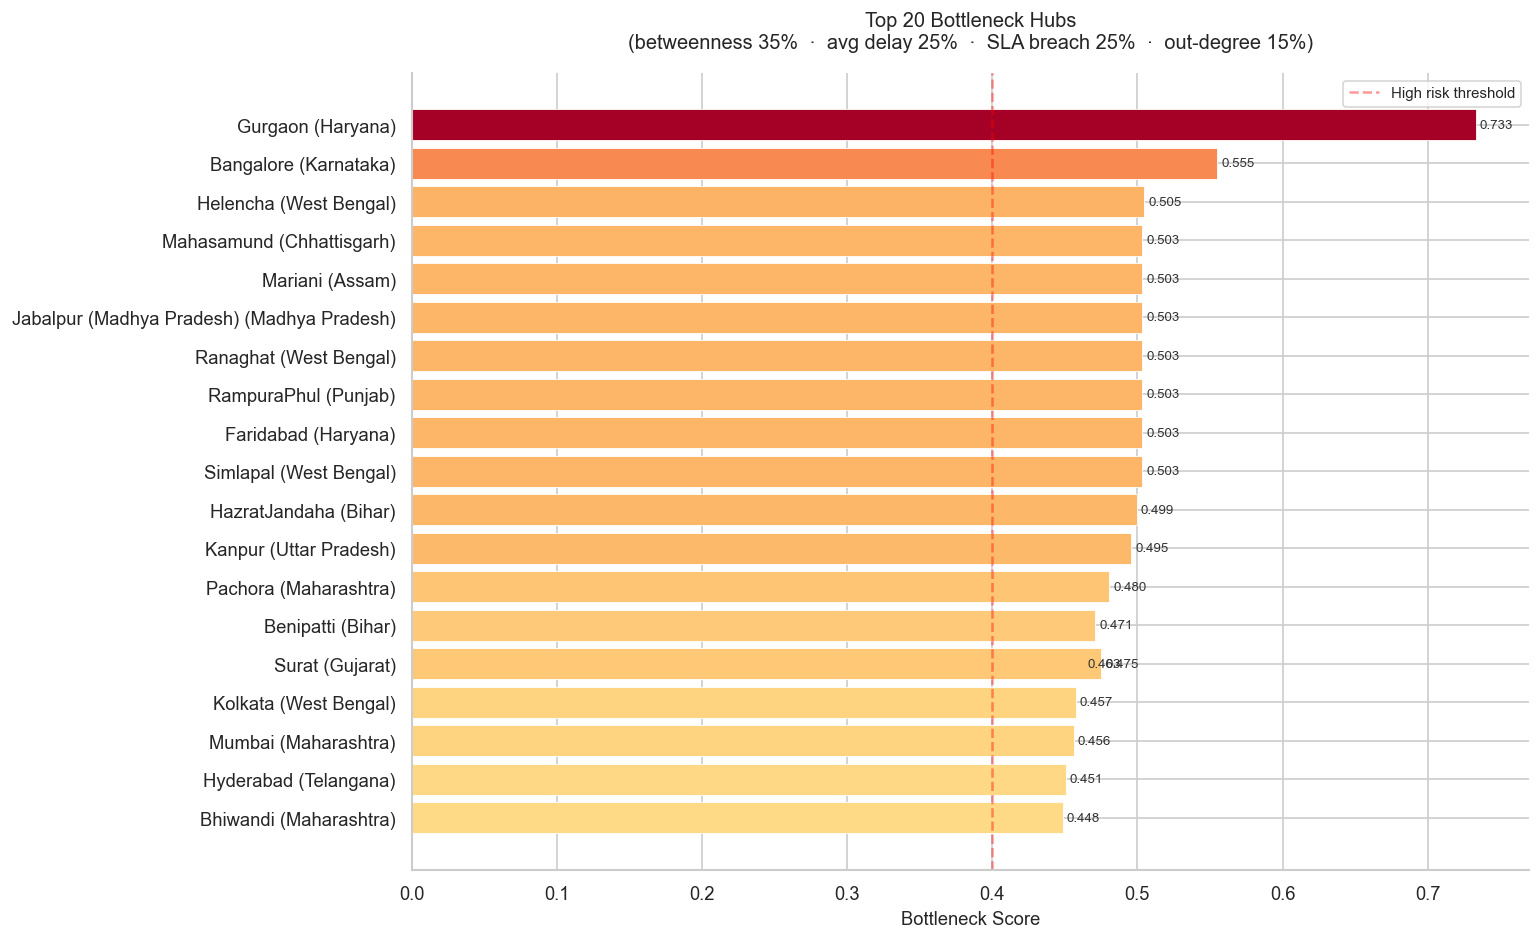

Saved 01_bottleneck_hubs_ranked.png


In [5]:
#top 20 bottlenecks hubs ranked 
top20 = node_metrics.head(20).copy()
 
# Shorten hub names for chart labels
top20["short_name"] = top20["hub_name"].apply(
    lambda x: x.split("_")[0] + " (" + x.split("(")[-1]
    if "(" in x else x.split("_")[0]
)
 
fig, ax = plt.subplots(figsize=(13, 8))
 
colors = plt.cm.RdYlGn_r(top20["bottleneck_score"] / top20["bottleneck_score"].max())
bars = ax.barh(
    top20["short_name"][::-1],
    top20["bottleneck_score"][::-1],
    color=colors[::-1],
    edgecolor="white",
    linewidth=0.5
)
 
# Score labels on each bar
for bar, score in zip(bars, top20["bottleneck_score"][::-1]):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center", fontsize=8, color="#333"
    )
 
ax.axvline(x=0.4, color="red", linestyle="--", alpha=0.4, label="High risk threshold")
ax.set_xlabel("Bottleneck Score", fontsize=11)
ax.set_title(
    "Top 20 Bottleneck Hubs\n"
    "(betweenness 35%  ·  avg delay 25%  ·  SLA breach 25%  ·  out-degree 15%)",
    fontsize=12, pad=15
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/01_bottleneck_hubs_ranked.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 01_bottleneck_hubs_ranked.png")

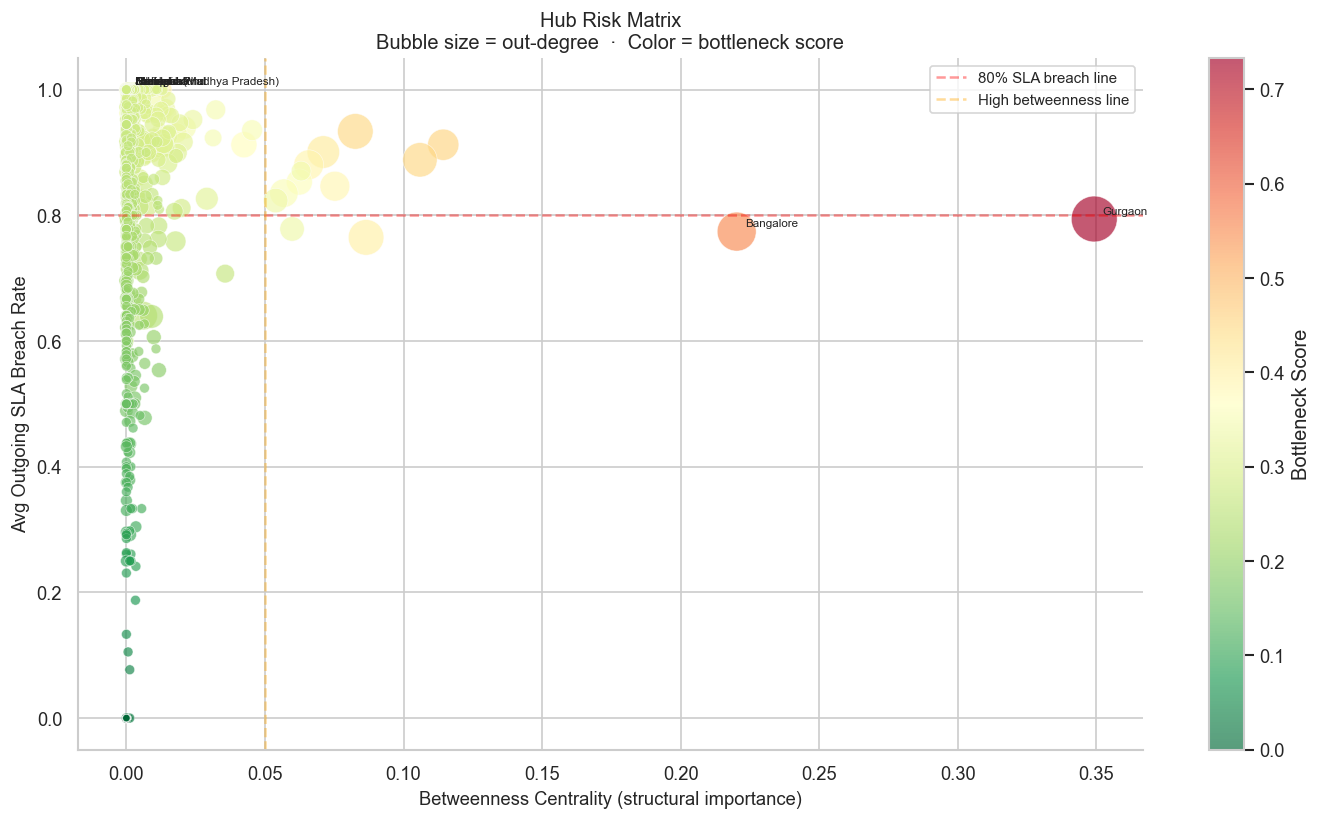

Saved 02_hub_risk_matrix.png


In [6]:
#Hub risk matrix scatter plot

# X axis = betweenness centrality (structural importance)
# Y axis = SLA breach rate (actual delay severity)
# Bubble size = out-degree (how many corridors affected)
# Color = bottleneck score
#
# Top right quadrant = most dangerous hubs
# Big bubbles top right = highest priority to fix

fig, ax = plt.subplots(figsize=(12, 7))
 
# Only plot hubs in the main connected network
main_net = node_metrics[node_metrics["in_wcc"] == 1].copy()
 
scatter = ax.scatter(
    main_net["betweenness_centrality"],
    main_net["avg_outgoing_sla_breach"],
    s=main_net["out_degree"] * 15 + 20,
    c=main_net["bottleneck_score"],
    cmap="RdYlGn_r",
    alpha=0.65,
    edgecolors="white",
    linewidth=0.4
)
plt.colorbar(scatter, ax=ax, label="Bottleneck Score")
 
# Label the top 10 hubs
for _, row in node_metrics.head(10).iterrows():
    ax.annotate(
        row["hub_name"].split("_")[0],
        (row["betweenness_centrality"], row["avg_outgoing_sla_breach"]),
        fontsize=7, ha="left",
        xytext=(5, 3), textcoords="offset points",
        color="#222"
    )
 
# Reference lines
ax.axhline(y=0.8, color="red", linestyle="--", alpha=0.4, label="80% SLA breach line")
ax.axvline(x=0.05, color="orange", linestyle="--", alpha=0.4, label="High betweenness line")
 
ax.set_xlabel("Betweenness Centrality (structural importance)", fontsize=11)
ax.set_ylabel("Avg Outgoing SLA Breach Rate", fontsize=11)
ax.set_title(
    "Hub Risk Matrix\n"
    "Bubble size = out-degree  ·  Color = bottleneck score",
    fontsize=12
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/02_hub_risk_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 02_hub_risk_matrix.png")

In [7]:
cols_to_show = [
    "bottleneck_rank", "hub_name", "state",
    "in_degree", "out_degree",
    "betweenness_centrality",
    "avg_outgoing_factor",
    "avg_outgoing_sla_breach",
    "bottleneck_score"
]
 
print("TOP 10 BOTTLENECK HUBS")
print("=" * 100)
display_df = node_metrics[cols_to_show].head(10).copy()
display_df["betweenness_centrality"] = display_df["betweenness_centrality"].round(4)
display_df["avg_outgoing_factor"]    = display_df["avg_outgoing_factor"].round(3)
display_df["avg_outgoing_sla_breach"]= display_df["avg_outgoing_sla_breach"].round(3)
display_df["bottleneck_score"]       = display_df["bottleneck_score"].round(4)
 
# In Jupyter this renders as a styled HTML table
display_df.style.background_gradient(subset=["bottleneck_score"], cmap="RdYlGn_r")

TOP 10 BOTTLENECK HUBS


,bottleneck_rank,hub_name,state,in_degree,out_degree,betweenness_centrality,avg_outgoing_factor,avg_outgoing_sla_breach,bottleneck_score
0,1,Gurgaon_Bilaspur_HB (Haryana),Haryana,45,49,0.349200,1.599000,0.794000,0.733000
1,2,Bangalore_Nelmngla_H (Karnataka),Karnataka,36,35,0.220200,1.544000,0.774000,0.554600
2,3,Helencha_ColnyDPP_D (West Bengal),West Bengal,1,1,0.001600,11.600000,1.000000,0.504700
3,4,Mahasamund_RajpurRD_D (Chhattisgarh),Chhattisgarh,1,1,0.000000,11.600000,1.000000,0.503100
4,5,Mariani_Mainroad_D (Assam),Assam,1,1,0.000000,11.600000,1.000000,0.503100
5,6,Jabalpur (Madhya Pradesh),Madhya Pradesh,1,1,0.000000,11.600000,1.000000,0.503100
6,7,Ranaghat_ArickDPP_D (West Bengal),West Bengal,1,1,0.000000,11.600000,1.000000,0.503100
7,8,RampuraPhul_DC (Punjab),Punjab,1,1,0.000000,11.600000,1.000000,0.503100
8,9,Faridabad_Old (Haryana),Haryana,1,1,0.000000,11.600000,1.000000,0.503100
9,10,Simlapal_Central_D_1 (West Bengal),West Bengal,1,1,0.000000,11.600000,1.000000,0.503100


In [8]:
# Part 2 — Corridor Level Audit
#
# A corridor is **chronically delayed** if:
# - median_factor > 1.2 (actual consistently > OSRM by 20%)
# - sla_breach_rate > 0.5 (more than half of trips are late)
# - trip_count > 10 (enough data to be confident)
#
# We then rank chronic corridors by **SLA contribution**
# = breach_rate × trip_count
# This measures actual business impact, not just percentage.

In [9]:
#identify and save chronic corridors
chronic = corridor_aggregates[
    (corridor_aggregates["median_factor"] > 1.2) &
    (corridor_aggregates["sla_breach_rate"] > 0.5) &
    (corridor_aggregates["trip_count"] > 10)
].copy()
 
# SLA contribution = how many late deliveries this corridor produces
chronic["sla_contribution"] = chronic["sla_breach_rate"] * chronic["trip_count"]
chronic = chronic.sort_values("sla_contribution", ascending=False).reset_index(drop=True)
chronic["chronic_rank"] = chronic.index + 1
 
# Add hub names for readability
hub_names = node_metrics[["hub_id", "hub_name"]].copy()
chronic = chronic.merge(
    hub_names.rename(columns={"hub_id": "source_center", "hub_name": "source_name_clean"}),
    on="source_center", how="left"
)
chronic = chronic.merge(
    hub_names.rename(columns={"hub_id": "destination_center", "hub_name": "dest_name_clean"}),
    on="destination_center", how="left"
)
chronic["corridor_label"] = (
    chronic["source_name_clean"].str.split("_").str[0] + " → " +
    chronic["dest_name_clean"].str.split("_").str[0]
)
 
chronic.to_csv(f"{OUT_DIR}/chronic_corridors.csv", index=False)
 
print(f"Total corridors           : {len(corridor_aggregates)}")
print(f"Chronic corridors flagged : {len(chronic)}")
print(f"  ({len(chronic)/len(corridor_aggregates):.1%} of all corridors are chronically delayed)")
print()
print("Top 10 chronic corridors by SLA contribution:")
chronic[["chronic_rank","corridor_label","median_factor","sla_breach_rate","trip_count","sla_contribution"]].head(10)
 

Total corridors           : 2783
Chronic corridors flagged : 953
  (34.2% of all corridors are chronically delayed)

Top 10 chronic corridors by SLA contribution:


,chronic_rank,corridor_label,median_factor,sla_breach_rate,trip_count,sla_contribution
0,1,Bangalore → Bengaluru,1.454545,0.742760,151,112.156729
1,2,Bhiwandi → Mumbai Hub (Maharashtra),2.236111,0.968750,105,101.718750
2,3,Mumbai → Bhiwandi,2.477273,0.978992,99,96.920168
3,4,Bangalore → Bengaluru,1.440000,0.745562,127,94.686391
4,5,Bengaluru → Bengaluru,1.529412,0.704132,121,85.200000
5,6,Pune → Bhiwandi,1.379310,0.739884,107,79.167630
6,7,Bhiwandi → Mumbai,2.444444,1.000000,78,78.000000
7,8,Bengaluru → Bangalore,1.400000,0.738609,102,75.338129
8,9,Mumbai Hub (Maharashtra) → Mumbai,2.714286,0.993056,72,71.500000
9,10,Bengaluru → Bangalore,1.363636,0.648855,108,70.076336


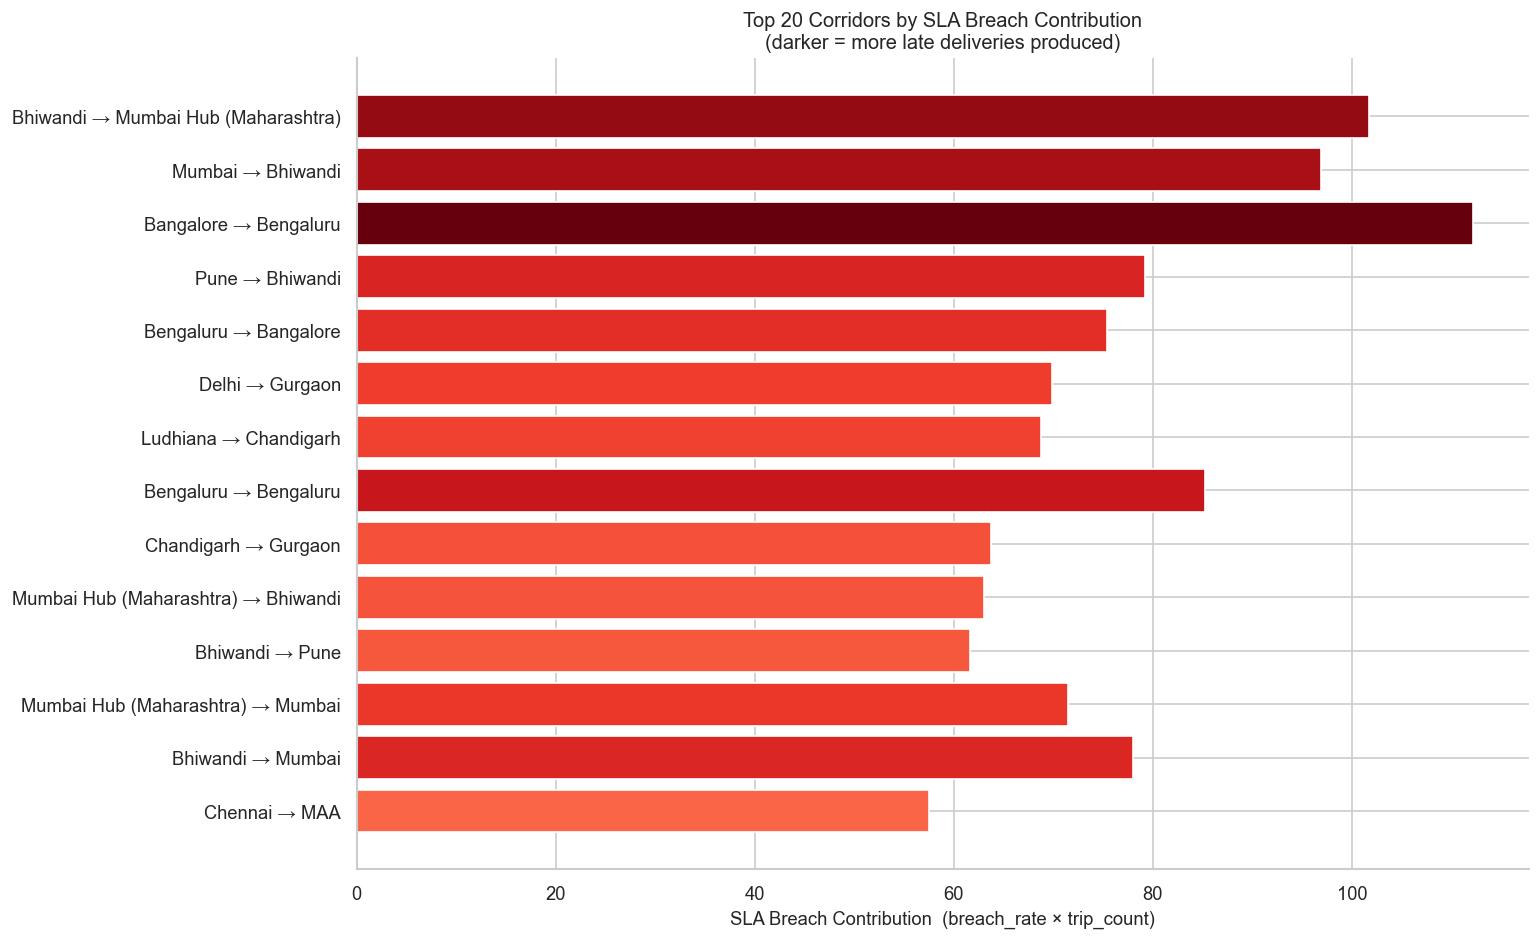

Saved 03_chronic_corridors.png


In [10]:
#bar chart saving for top 20 chronics 
top20c = chronic.head(20).copy()
 
fig, ax = plt.subplots(figsize=(13, 8))
colors3 = plt.cm.Reds(top20c["sla_contribution"] / top20c["sla_contribution"].max())
ax.barh(
    top20c["corridor_label"][::-1],
    top20c["sla_contribution"][::-1],
    color=colors3[::-1],
    edgecolor="white"
)
ax.set_xlabel("SLA Breach Contribution  (breach_rate × trip_count)", fontsize=11)
ax.set_title(
    "Top 20 Corridors by SLA Breach Contribution\n"
    "(darker = more late deliveries produced)",
    fontsize=12
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/03_chronic_corridors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 03_chronic_corridors.png")

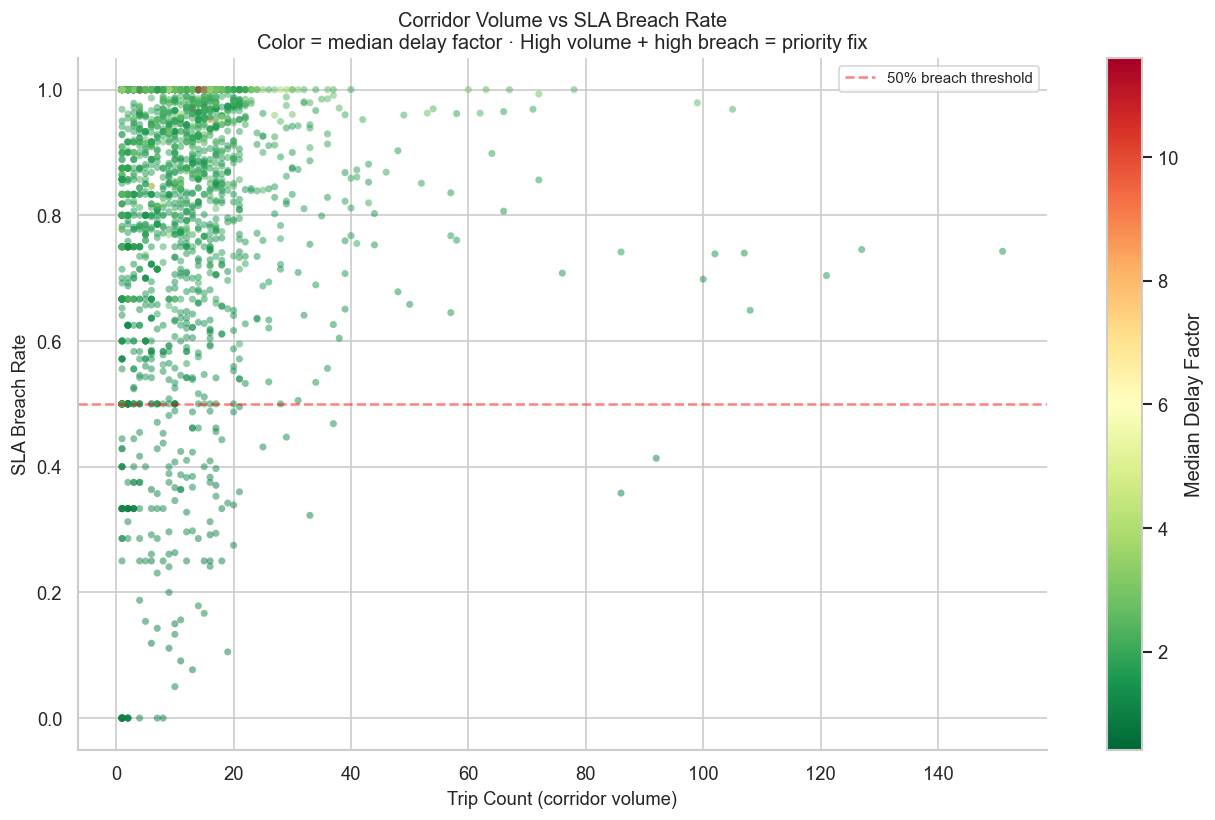

Saved 04_corridor_volume_vs_breach.png


In [11]:
#Trip volume vs SLA breach rate scatter
# High volume + high breach = worst corridors (top right)
# Low volume + high breach  = bad but low impact
# High volume + low breach  = healthy busy corridors
# ============================================================
 
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    corridor_aggregates["trip_count"],
    corridor_aggregates["sla_breach_rate"],
    c=corridor_aggregates["median_factor"],
    cmap="RdYlGn_r",
    alpha=0.5, s=18,
    edgecolors="none"
)
sm = plt.cm.ScalarMappable(
    cmap="RdYlGn_r",
    norm=plt.Normalize(
        corridor_aggregates["median_factor"].min(),
        corridor_aggregates["median_factor"].max()
    )
)
plt.colorbar(sm, ax=ax, label="Median Delay Factor")
 
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="50% breach threshold")
ax.set_xlabel("Trip Count (corridor volume)", fontsize=11)
ax.set_ylabel("SLA Breach Rate", fontsize=11)
ax.set_title(
    "Corridor Volume vs SLA Breach Rate\n"
    "Color = median delay factor · High volume + high breach = priority fix",
    fontsize=12
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/04_corridor_volume_vs_breach.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 04_corridor_volume_vs_breach.png")
 
 

In [12]:
corridor_aggregates["trip_count"].describe()

count    2783.000000
mean        9.474668
std        11.254234
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max       151.000000
Name: trip_count, dtype: float64

In [13]:
print(corridor_aggregates["trip_count"].describe())
print()
print("Corridors with < 20 trips:", (corridor_aggregates["trip_count"] < 20).sum())
print("Corridors with 20-100 trips:", corridor_aggregates["trip_count"].between(20,100).sum())
print("Corridors with 100+ trips:", (corridor_aggregates["trip_count"] >= 100).sum())
print()
# What % of total trips do the top 10% of corridors carry
top10pct = corridor_aggregates.nlargest(int(len(corridor_aggregates)*0.1), "trip_count")
print(f"Top 10% of corridors carry {top10pct['trip_count'].sum() / corridor_aggregates['trip_count'].sum():.1%} of all trips")

count    2783.000000
mean        9.474668
std        11.254234
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max       151.000000
Name: trip_count, dtype: float64

Corridors with < 20 trips: 2515
Corridors with 20-100 trips: 261
Corridors with 100+ trips: 8

Top 10% of corridors carry 34.1% of all trips


In [14]:
# Part 3 — Network Level Audit
# We now zoom out from individual hubs and corridors
# to look at patterns across the whole network:
# - Which **states** have the worst delay?
# - Which **time of day** is worst?
# - Does **FTL vs Carting** behave differently across the network?

In [15]:
state_metrics = node_metrics.groupby("state").agg(
    hub_count            = ("hub_id", "count"),
    avg_bottleneck_score = ("bottleneck_score", "mean"),
    avg_sla_breach       = ("avg_outgoing_sla_breach", "mean"),
    avg_delay_factor     = ("avg_outgoing_factor", "mean"),
    max_bottleneck       = ("bottleneck_score", "max"),
    total_out_degree     = ("out_degree", "sum"),
).reset_index().sort_values("avg_sla_breach", ascending=False)
 
print("State-level summary (top 10 by SLA breach rate):")
state_metrics.head(10).style.background_gradient(subset=["avg_sla_breach"], cmap="RdYlGn_r")
 

State-level summary (top 10 by SLA breach rate):


,state,hub_count,avg_bottleneck_score,avg_sla_breach,avg_delay_factor,max_bottleneck,total_out_degree
6,Dadra and Nagar Haveli,1,0.321069,1.000000,3.155556,0.321069,1
21,Nagaland,1,0.312764,1.000000,2.770202,0.312764,1
20,Mizoram,3,0.336513,1.000000,3.846814,0.351840,3
2,Assam,47,0.301652,0.928246,2.771871,0.503061,87
0,Andhra Pradesh,80,0.279002,0.910456,2.021472,0.378227,144
19,Meghalaya,3,0.278839,0.900000,2.248664,0.304749,4
22,Orissa,46,0.271941,0.870125,2.232238,0.401251,70
23,Pondicherry,2,0.277448,0.865741,2.312833,0.322528,4
9,Goa,8,0.265271,0.850138,2.038170,0.363859,18
32,West Bengal,114,0.270648,0.836569,2.522443,0.504704,185


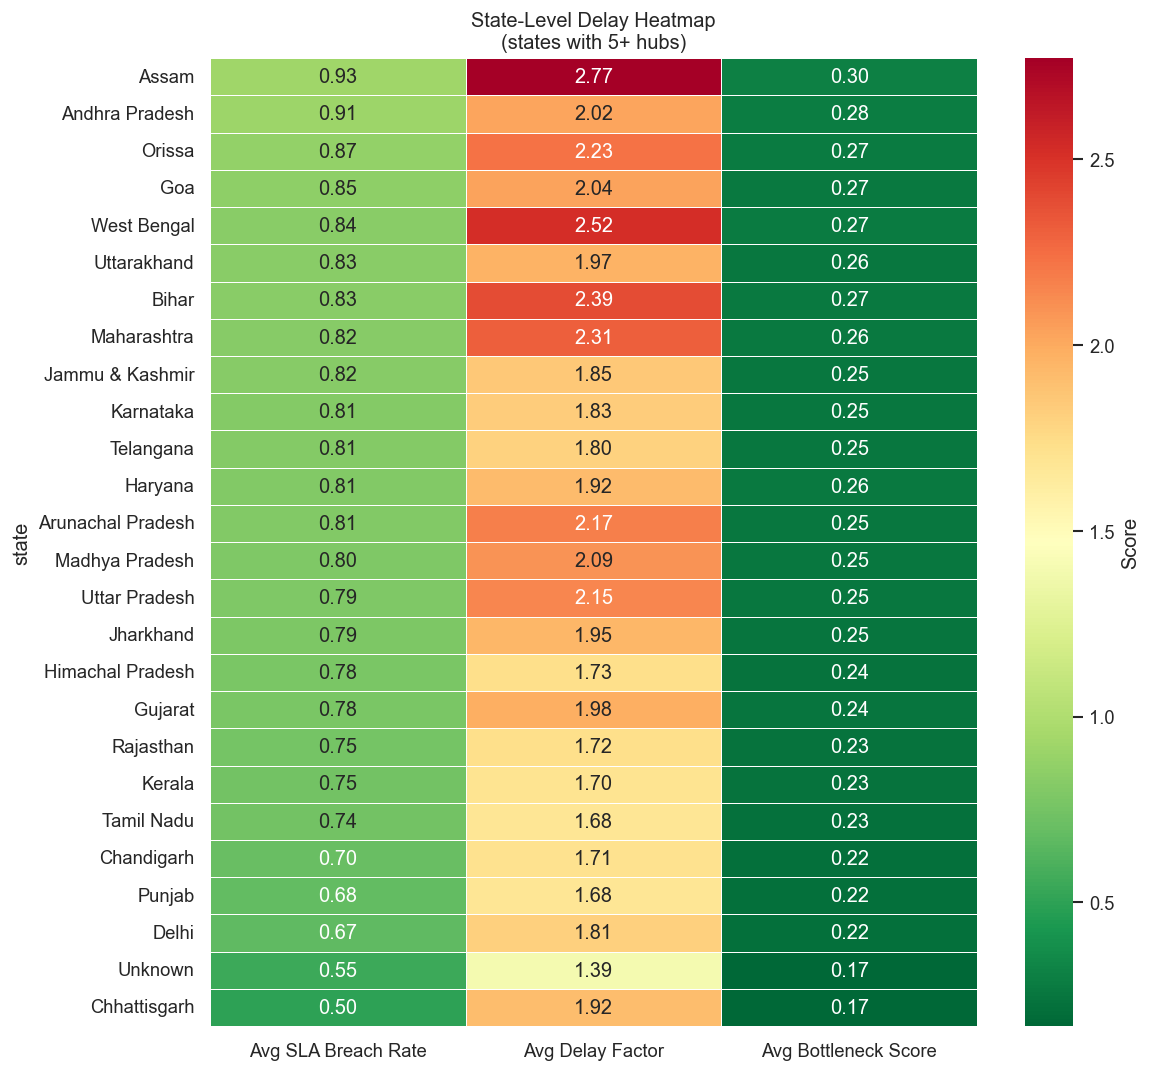

Saved 05_state_heatmap.png


In [16]:
top_states = state_metrics[state_metrics["hub_count"] >= 5].copy()
 
heatmap_data = top_states.set_index("state")[[
    "avg_sla_breach",
    "avg_delay_factor",
    "avg_bottleneck_score"
]].round(3)
heatmap_data.columns = ["Avg SLA Breach Rate", "Avg Delay Factor", "Avg Bottleneck Score"]
 
fig, ax = plt.subplots(figsize=(10, max(6, len(top_states) * 0.35)))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".2f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Score"}
)
ax.set_title("State-Level Delay Heatmap\n(states with 5+ hubs)", fontsize=12)
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/05_state_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 05_state_heatmap.png")


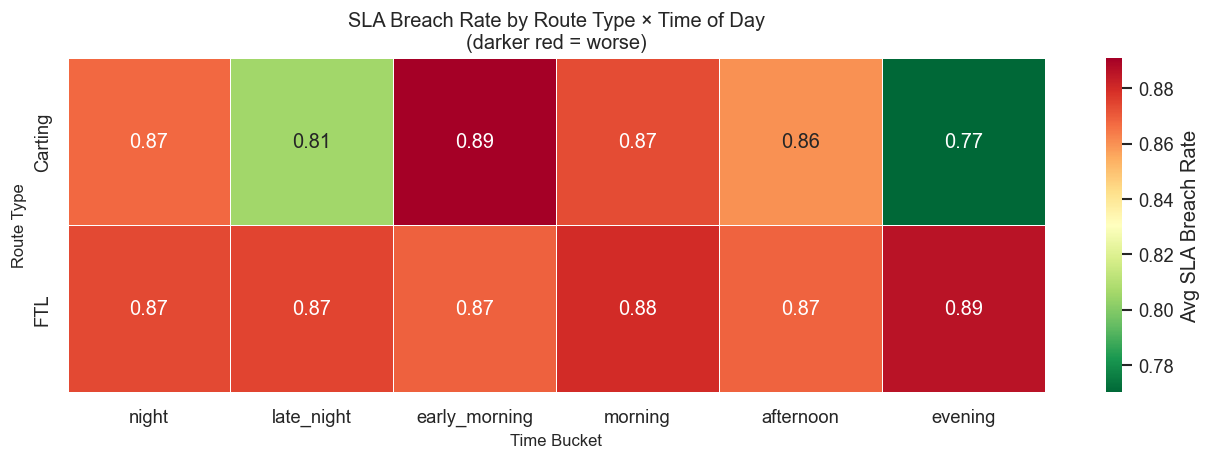

Saved 06_routetype_timebucket_heatmap.png


In [17]:

time_order = ["night", "late_night", "early_morning", "morning", "afternoon", "evening"]
 
pivot = (
    corridor_stratified
    .groupby(["route_type", "time_bucket"])["sla_breach_rate"]
    .mean()
    .unstack()
)
pivot = pivot.reindex(columns=[t for t in time_order if t in pivot.columns])
 
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    pivot,
    annot=True, fmt=".2f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Avg SLA Breach Rate"}
)
ax.set_title("SLA Breach Rate by Route Type × Time of Day\n(darker red = worse)", fontsize=12)
ax.set_xlabel("Time Bucket", fontsize=10)
ax.set_ylabel("Route Type", fontsize=10)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/06_routetype_timebucket_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 06_routetype_timebucket_heatmap.png")

FTL vs Carting — network-wide stats:
route_type  median_factor  avg_sla_breach  total_trips  corridor_count
   Carting       1.958333        0.854327        12429            1980
       FTL       1.775986        0.874496        13940            2585



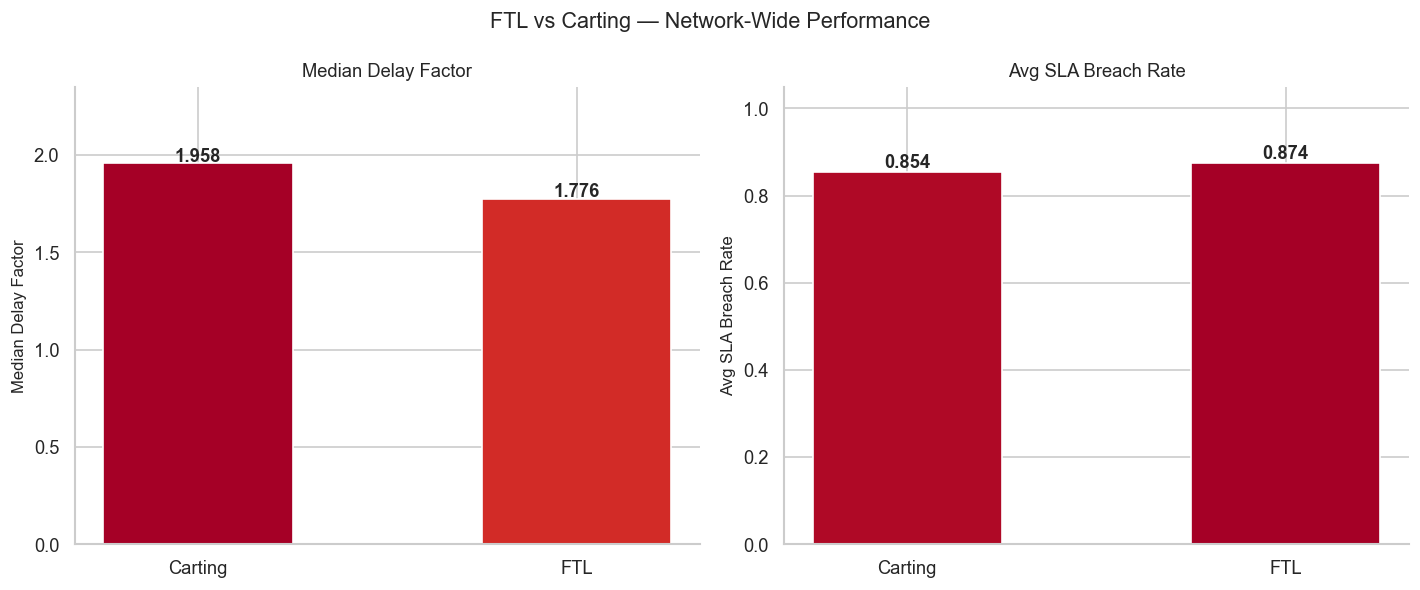

Saved 07_ftl_vs_carting.png


In [18]:
ftl_carting = corridor_stratified.groupby("route_type").agg(
    median_factor  = ("median_factor", "median"),
    avg_sla_breach = ("sla_breach_rate", "mean"),
    total_trips    = ("trip_count", "sum"),
    corridor_count = ("source_center", "count"),
).reset_index()
 
print("FTL vs Carting — network-wide stats:")
print(ftl_carting.to_string(index=False))
print()
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for ax, (col, label) in zip(axes, [
    ("median_factor",  "Median Delay Factor"),
    ("avg_sla_breach", "Avg SLA Breach Rate"),
]):
    vals = ftl_carting[col]
    colors_bar = [plt.cm.RdYlGn_r(v / vals.max()) for v in vals]
    bars = ax.bar(ftl_carting["route_type"], vals, color=colors_bar, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold"
        )
    ax.set_title(label, fontsize=11)
    ax.set_ylabel(label, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(0, vals.max() * 1.2)
 
fig.suptitle("FTL vs Carting — Network-Wide Performance", fontsize=13)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/07_ftl_vs_carting.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 07_ftl_vs_carting.png")

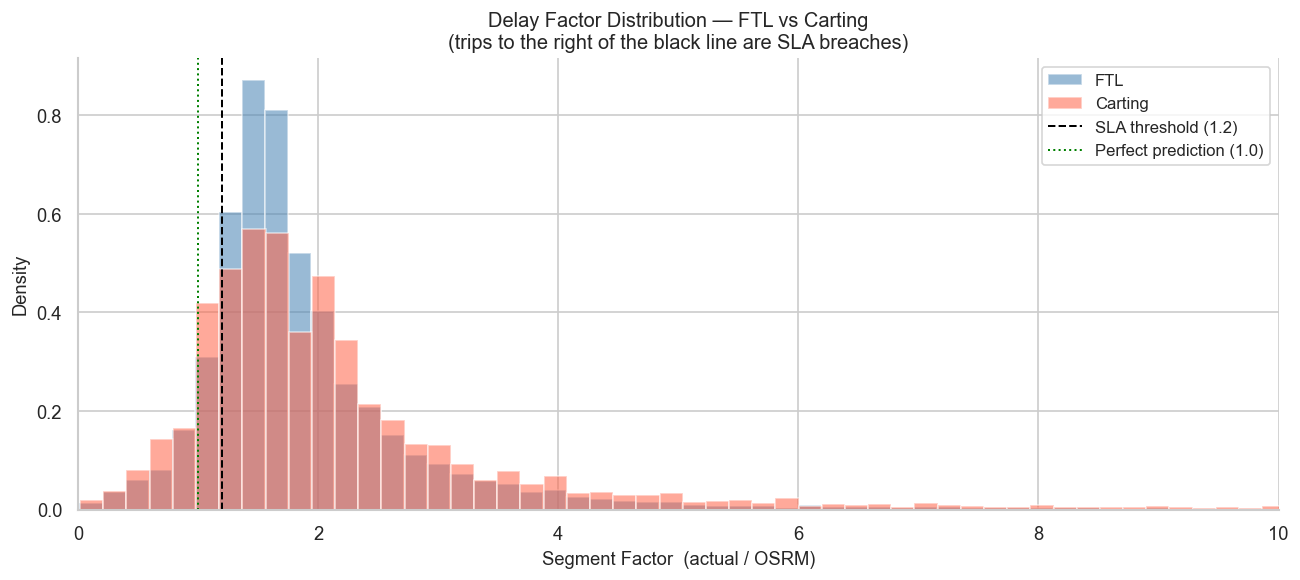

Saved 08_delay_distribution.png


In [19]:
# CELL 13 — Delay factor distribution — FTL vs Carting
#
# Shows the full shape of delay for both route types
# Not just averages — shows the tail risk too
# ============================================================
 
fig, ax = plt.subplots(figsize=(11, 5))
 
for rt, color in [("FTL", "steelblue"), ("Carting", "tomato")]:
    subset = train_df[train_df["route_type"] == rt]["segment_factor_capped"]
    ax.hist(subset, bins=60, alpha=0.55, color=color, label=rt, density=True)
 
ax.axvline(x=1.2, color="black", linestyle="--", linewidth=1.2, label="SLA threshold (1.2)")
ax.axvline(x=1.0, color="green", linestyle=":", linewidth=1.2, label="Perfect prediction (1.0)")
 
ax.set_xlabel("Segment Factor  (actual / OSRM)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Delay Factor Distribution — FTL vs Carting\n(trips to the right of the black line are SLA breaches)", fontsize=12)
ax.set_xlim(0, 10)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/08_delay_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 08_delay_distribution.png")

In [20]:
# ## Part 4 — Graph Visualization
#
# We visualize only the top 30 bottleneck hubs —
# plotting the full 1,657-node graph produces a black blob.
# Node size = betweenness centrality
# Node color = SLA breach rate (red = worse)

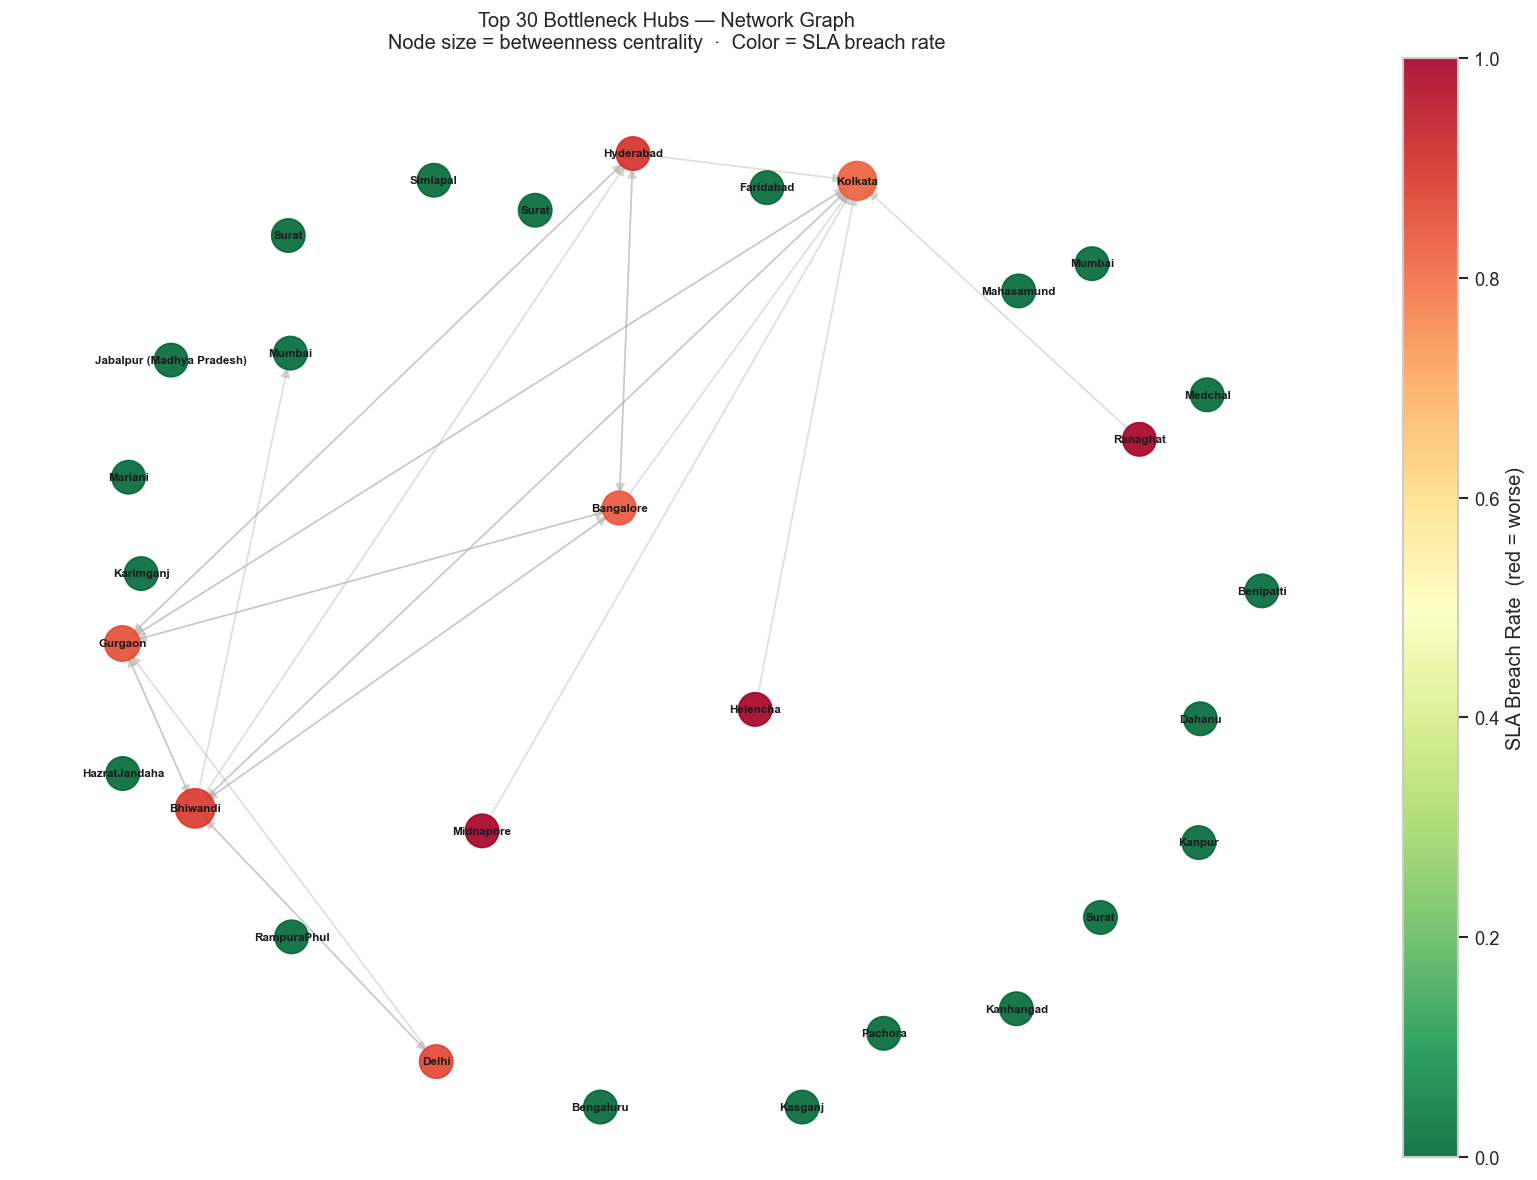

Saved 09_network_graph_top30.png


In [21]:
top30_ids = node_metrics.head(30)["hub_id"].tolist()
subgraph  = G.subgraph(top30_ids)
pos       = nx.spring_layout(subgraph, seed=42, k=2.5)
 
# Node sizes from betweenness
btw        = nx.betweenness_centrality(subgraph)
node_sizes = [6000 * btw.get(n, 0.01) + 400 for n in subgraph.nodes]
 
# Node colors from SLA breach rate
sla_scores = []
for n in subgraph.nodes:
    out_edges = [
        d["sla_breach_rate"]
        for _, _, d in subgraph.out_edges(n, data=True)
        if "sla_breach_rate" in d
    ]
    sla_scores.append(float(np.mean(out_edges)) if out_edges else 0)
 
fig, ax = plt.subplots(figsize=(14, 10))
 
nodes_draw = nx.draw_networkx_nodes(
    subgraph, pos,
    node_size=node_sizes,
    node_color=sla_scores,
    cmap=plt.cm.RdYlGn_r,
    alpha=0.9, ax=ax
)
nx.draw_networkx_edges(
    subgraph, pos,
    arrows=True, arrowsize=12,
    edge_color="#aaa", alpha=0.4,
    width=1.0, ax=ax
)
nx.draw_networkx_labels(
    subgraph, pos,
    labels={n: G.nodes[n].get("name", "").split("_")[0] for n in subgraph.nodes},
    font_size=7, font_weight="bold", ax=ax
)
 
plt.colorbar(nodes_draw, ax=ax, label="SLA Breach Rate  (red = worse)")
ax.set_title(
    "Top 30 Bottleneck Hubs — Network Graph\n"
    "Node size = betweenness centrality  ·  Color = SLA breach rate",
    fontsize=12
)
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/09_network_graph_top30.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 09_network_graph_top30.png")

In [22]:
bottleneck_ranked = node_metrics[[
    "bottleneck_rank", "hub_id", "hub_name", "state",
    "in_degree", "out_degree",
    "betweenness_centrality",
    "avg_outgoing_factor",
    "avg_outgoing_sla_breach",
    "bottleneck_score"
]].copy()
 
bottleneck_ranked.to_csv(f"{OUT_DIR}/bottleneck_hubs_ranked.csv", index=False)
print(f"Saved bottleneck_hubs_ranked.csv  ({len(bottleneck_ranked)} hubs)")
 

Saved bottleneck_hubs_ranked.csv  (1657 hubs)


In [23]:
sla_contribution = corridor_aggregates.copy()
sla_contribution["sla_contribution"] = (
    sla_contribution["sla_breach_rate"] * sla_contribution["trip_count"]
)
sla_contribution = sla_contribution.sort_values(
    "sla_contribution", ascending=False
).reset_index(drop=True)
 
sla_contribution.to_csv(f"{OUT_DIR}/sla_contribution.csv", index=False)
print(f"Saved sla_contribution.csv  ({len(sla_contribution)} corridors)")

Saved sla_contribution.csv  (2783 corridors)


In [24]:
print("=" * 55)
print("  PHASE 2 COMPLETE")
print("=" * 55)
print()
print("KEY FINDINGS:")
print()
print(f"  Top bottleneck hub    : {node_metrics.iloc[0]['hub_name']}")
print(f"  State                 : {node_metrics.iloc[0]['state']}")
print(f"  Bottleneck score      : {node_metrics.iloc[0]['bottleneck_score']:.4f}")
print(f"  Betweenness           : {node_metrics.iloc[0]['betweenness_centrality']:.4f}")
print()
print(f"  Chronic corridors     : {len(chronic)} / {len(corridor_aggregates)} ({len(chronic)/len(corridor_aggregates):.1%})")
print(f"  Top chronic corridor  : {chronic.iloc[0]['corridor_label']}")
print(f"  SLA contribution      : {chronic.iloc[0]['sla_contribution']:.0f} late deliveries")
print()
top_state = state_metrics.iloc[0]
print(f"  Worst state           : {top_state['state']}")
print(f"  Avg SLA breach rate   : {top_state['avg_sla_breach']:.1%}")
print()
print("data/processed SAVED:")
processed = [
    ("bottleneck_hubs_ranked.csv", "hub rankings for Phase 5 memo"),
    ("chronic_corridors.csv",      "flagged corridors for Phase 4"),
    ("sla_contribution.csv",       "corridor business impact"),
    ("phase2_visuals/",            "9 charts"),
]
for fname, desc in processed:
    print(f"  data/processed/{fname:<35} ← {desc}")
print()
print("  → Phase 3: ETA prediction model")

  PHASE 2 COMPLETE

KEY FINDINGS:

  Top bottleneck hub    : Gurgaon_Bilaspur_HB (Haryana)
  State                 : Haryana
  Bottleneck score      : 0.7330
  Betweenness           : 0.3492

  Chronic corridors     : 953 / 2783 (34.2%)
  Top chronic corridor  : Bangalore → Bengaluru
  SLA contribution      : 112 late deliveries

  Worst state           : Dadra and Nagar Haveli
  Avg SLA breach rate   : 100.0%

data/processed SAVED:
  data/processed/bottleneck_hubs_ranked.csv          ← hub rankings for Phase 5 memo
  data/processed/chronic_corridors.csv               ← flagged corridors for Phase 4
  data/processed/sla_contribution.csv                ← corridor business impact
  data/processed/phase2_visuals/                     ← 9 charts

  → Phase 3: ETA prediction model
